# Week 5 — LOF on Latent z

**Kế hoạch (đề cương §6.2, §6.7):**
1. Load Week 4 artifacts (`z_benign_train`, `z_val`, `y_val_8`, `y_val_34`, Week 4 JSON summary).
2. StandardScaler trên z (bắt buộc vì std các dim lệch ~5×).
3. Sample 100k benign từ 878k train → fit LOF ball_tree.
4. Ablation k ∈ {10, 20, 50, 100}.
5. Threshold @ FPR ∈ {1%, 5%, 10%} trên val-benign.
6. Metrics: TPR, F1-macro (8-class & 34-class), per-class F1.
7. So sánh LOF vs recon-MSE (Week 4 baseline).
8. Save artifacts cho Week 6 (baseline retraining) và Week 10 (Pareto plot).

**Top-1 config từ Week 4:** ρ=0.05, β=1.0 (recon-MSE AUC = 0.9958).

**Threshold convention:** `score = -lof.score_samples(z)` → dương càng cao = càng outlier.  
**FPR calibration:** tính trên val-benign (109,820 samples); predict as attack nếu score > τ.

---

**Output deliverables:**
- `results/week5/week5_lof_ablation.csv` — bảng k × FPR_target với AUC/TPR/F1
- `results/week5/week5_lof_vs_recon.csv` — so sánh 2 scorer trên cùng metrics
- `results/week5/week5_final_summary.json` — bản tóm tắt cho §Results paper
- `results/week5/lof_scores_val.npy` — scores (float32) cho Week 10 Pareto
- `results/week5/lof_best_k.pkl` — model pickle cho Week 6-7 deploy
- `results/week5/scaler_z.pkl` — StandardScaler pickle
- `figs/week5/05_roc_overlay.png` — ROC LOF vs recon-MSE
- `figs/week5/05_k_ablation.png` — F1 vs k
- `figs/week5/05_confmat_8class.png` — confusion matrix 8-class
- `figs/week5/05_confmat_34class.png` — confusion matrix 34-class
- `figs/week5/05_per_class_f1.png` — per-class F1 bar chart

### Cell 1 — Mount Drive + imports

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import sys, os, time, json, pickle, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, confusion_matrix,
    classification_report, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print('Python:', sys.version.split()[0])
import sklearn
print('sklearn:', sklearn.__version__)
print('numpy  :', np.__version__)

Mounted at /content/drive
Python: 3.12.13
sklearn: 1.6.1
numpy  : 2.0.2


### Cell 2 — Paths + constants

In [2]:
PROJ_ROOT = Path('/content/drive/MyDrive/sae-lof-ids-pi5')
WEEK4_DIR = PROJ_ROOT / 'results' / 'week4'
RESULT_DIR = PROJ_ROOT / 'results' / 'week5'
FIG_DIR    = PROJ_ROOT / 'figs' / 'week5'
CKPT_DIR   = PROJ_ROOT / 'checkpoints' / 'week5'

for d in (RESULT_DIR, FIG_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Input artifacts from Week 4
Z_BENIGN_FP = WEEK4_DIR / 'z_benign_train_top1_seed0.npy'
Z_VAL_FP    = WEEK4_DIR / 'z_val_top1_seed0.npy'
Y8_FP       = WEEK4_DIR / 'y_val_8class_top1_seed0.npy'
Y34_FP      = WEEK4_DIR / 'y_val_34class_top1_seed0.npy'
W4_JSON     = WEEK4_DIR / 'week4_final_summary.json'

# Constants
BENIGN_LABEL = 0
SAMPLE_SIZE_FIT = 100_000
K_VALUES     = [10, 20, 50, 100]
FPR_TARGETS  = [0.01, 0.05, 0.10]
RNG_SEED     = 0

print(f'PROJ_ROOT   = {PROJ_ROOT}')
print(f'WEEK4_DIR   = {WEEK4_DIR}')
print(f'RESULT_DIR  = {RESULT_DIR}')
print(f'\nHyperparameters:')
print(f'  sample size for LOF fit : {SAMPLE_SIZE_FIT:,}')
print(f'  k values ablation       : {K_VALUES}')
print(f'  FPR targets             : {FPR_TARGETS}')
print(f'  random seed             : {RNG_SEED}')

PROJ_ROOT   = /content/drive/MyDrive/sae-lof-ids-pi5
WEEK4_DIR   = /content/drive/MyDrive/sae-lof-ids-pi5/results/week4
RESULT_DIR  = /content/drive/MyDrive/sae-lof-ids-pi5/results/week5

Hyperparameters:
  sample size for LOF fit : 100,000
  k values ablation       : [10, 20, 50, 100]
  FPR targets             : [0.01, 0.05, 0.1]
  random seed             : 0


### Cell 3 — Load Week 4 artifacts + recon-MSE baseline

Ta load luôn cả `z_val` vào RAM (150MB — thoải mái trong Colab Pro+ High-RAM 51GB).

In [3]:
t0 = time.time()

z_benign = np.load(Z_BENIGN_FP).astype(np.float32)
z_val    = np.load(Z_VAL_FP).astype(np.float32)
y8       = np.load(Y8_FP).astype(np.int8)
y34      = np.load(Y34_FP).astype(np.int8)

with open(W4_JSON) as f:
    w4_summary = json.load(f)

top1 = w4_summary['grid']['best']
print(f'Week 4 top-1: ρ={top1["rho"]}, β={top1["beta"]}')
print(f'  recon-MSE AUC (single seed): {top1["auc"]:.5f}')
print(f'  recon-MSE FPR@TPR95 (seed 0): {top1["fpr_at_tpr95"]:.5f}')

print(f'\nLoaded arrays:')
print(f'  z_benign : {z_benign.shape}  ({z_benign.nbytes/1e6:.1f} MB)')
print(f'  z_val    : {z_val.shape}  ({z_val.nbytes/1e6:.1f} MB)')
print(f'  y8       : {y8.shape}  uniq={sorted(np.unique(y8).tolist())}')
print(f'  y34      : {y34.shape}  n_uniq={len(np.unique(y34))}')

# Sanity: z_val & y must have matching length
assert len(z_val) == len(y8) == len(y34), 'Length mismatch!'

print(f'\nLoad time: {time.time()-t0:.1f}s')

Week 4 top-1: ρ=0.05, β=1.0
  recon-MSE AUC (single seed): 0.99583
  recon-MSE FPR@TPR95 (seed 0): 0.00418

Loaded arrays:
  z_benign : (878556, 8)  (28.1 MB)
  z_val    : (4668658, 8)  (149.4 MB)
  y8       : (4668658,)  uniq=[0, 1, 2, 3, 4, 5, 6, 7]
  y34      : (4668658,)  n_uniq=34

Load time: 9.7s


## Cell 3.5

In [8]:
# Recompute recon error cho val — FIXED v2
from pathlib import Path
import sys
import torch
import numpy as np
import pandas as pd

sys.path.insert(0, str(PROJ_ROOT / 'src'))
from sae_model import SparseAutoencoder

CKPT_W4 = PROJ_ROOT / 'checkpoints' / 'week4' / 'sae_v1_rho=0.05_beta=1.0_seed=0_best.pt'
VAL_PARQUET = PROJ_ROOT / 'data' / 'processed' / 'val.parquet'
RECON_FP = WEEK4_DIR / 'recon_err_val_seed0.npy'

if not RECON_FP.exists():
    print('Recomputing recon_err from checkpoint...')
    dfv = pd.read_parquet(VAL_PARQUET)
    print(f'Original shape: {dfv.shape}')

    # Exhaustive drop list — includes y_bin
    DROP_CANDIDATES = ['y_bin', 'y8', 'y34', 'Label', 'label', 'ts', 'timestamp',
                       'Attack', 'attack', 'class', 'Class', 'target', 'Target']
    cols_to_drop = [c for c in DROP_CANDIDATES if c in dfv.columns]
    print(f'Dropping: {cols_to_drop}')
    X_df = dfv.drop(columns=cols_to_drop)

    assert X_df.shape[1] == 46, (
        f'Expected 46 feature columns after drop, got {X_df.shape[1]}. '
        f'Remaining columns: {X_df.columns.tolist()}'
    )

    X_val = X_df.values.astype(np.float32)
    print(f'X_val shape: {X_val.shape}  (should be (4668658, 46))')
    print(f'Feature order: {X_df.columns.tolist()}')

    # Load model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = SparseAutoencoder(input_dim=46, hidden_dims=(32, 16), latent_dim=8).to(device)

    ckpt = torch.load(CKPT_W4, map_location=device)
    if 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
    elif 'state_dict' in ckpt:
        model.load_state_dict(ckpt['state_dict'])
    elif 'model' in ckpt:
        model.load_state_dict(ckpt['model'])
    else:
        model.load_state_dict(ckpt)
    model.eval()
    print(f'Model loaded on {device}')

    # Batched forward
    recon_errs = []
    B = 8192
    with torch.no_grad():
        for i in range(0, len(X_val), B):
            x = torch.from_numpy(X_val[i:i+B]).to(device)
            x_hat, _ = model(x)
            err = ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()
            recon_errs.append(err)
    recon_errs = np.concatenate(recon_errs).astype(np.float32)

    assert len(recon_errs) == 4_668_658, f'Length mismatch: {len(recon_errs)}'
    np.save(RECON_FP, recon_errs)
    print(f'✓ Saved {RECON_FP}')
    print(f'  shape={recon_errs.shape}')
    print(f'  range=[{recon_errs.min():.4f}, {recon_errs.max():.4f}]')
    print(f'  mean={recon_errs.mean():.4f}, std={recon_errs.std():.4f}')
else:
    print(f'✓ recon_err already exists: {RECON_FP}')
    recon_errs = np.load(RECON_FP)
    print(f'  shape={recon_errs.shape}')

# ---- Sanity check: verify AUC matches Week 4 reported ----
from sklearn.metrics import roc_auc_score
y8_tmp = np.load(Y8_FP)
y_binary_tmp = (y8_tmp != 0).astype(np.int8)
auc_check = roc_auc_score(y_binary_tmp, recon_errs)
print(f'\nSanity AUC check:')
print(f'  Recomputed: {auc_check:.5f}')
print(f'  Week 4 reported: {top1["auc"]:.5f}')
diff = abs(auc_check - top1['auc'])
if diff < 0.001:
    print(f'  ✓ Match (diff={diff:.5f} < 0.001)')
elif diff < 0.01:
    print(f'  ⚠ Small diff={diff:.5f} — could be acceptable (maybe different subsample)')
else:
    print(f'  ✗ MISMATCH (diff={diff:.5f}) — feature order likely wrong, investigate')

Recomputing recon_err from checkpoint...
Original shape: (4668658, 49)
Dropping: ['y_bin', 'y8', 'y34']
X_val shape: (4668658, 46)  (should be (4668658, 46))
Feature order: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']
Model loaded on cuda
✓ Saved /content/drive/MyDrive/sae-lof-ids-pi5/results/week4/recon_err_val_seed0.npy
  shape=(4668658,)
  range=[0.0005, 40676.3477]
  mean=280.9515, std=896.2958

Sanity AUC check:
  Recomputed: 0.99587
  Week 4 reported: 0.99583
  ✓ Match (diff=0.00004 < 0.001)


### Cell 4 — Benign/attack breakdown + dim diagnostics

Xác nhận phân bố và diagnose 3 dim low-variance (2, 3, 7 theo pre-flight check).

In [4]:
n_benign_val = (y8 == BENIGN_LABEL).sum()
n_attack_val = (y8 != BENIGN_LABEL).sum()

print('8-class distribution in val:')
for lab in sorted(np.unique(y8)):
    cnt = (y8 == lab).sum()
    tag = ' <- BENIGN' if lab == BENIGN_LABEL else ''
    print(f'  label {lab}: {cnt:>10,}  ({cnt/len(y8)*100:5.2f}%){tag}')

print(f'\nTotal val     : {len(y8):,}')
print(f'Total benign  : {n_benign_val:,}')
print(f'Total attack  : {n_attack_val:,}')
print(f'Benign ratio  : {n_benign_val/len(y8)*100:.2f}%')

# FPR target → absolute count of benign false alarms allowed
print(f'\nFPR calibration targets (on val-benign = {n_benign_val:,}):')
for fpr in FPR_TARGETS:
    allowed = int(n_benign_val * fpr)
    print(f'  FPR={fpr*100:4.1f}% → {allowed:>6,} benign may be misflagged')

# Latent dim diagnostics
print(f'\nLatent z diagnostics (z_benign):')
print(f'  {"dim":<5}{"mean":>10}{"std":>10}{"max":>10}')
for d in range(z_benign.shape[1]):
    col = z_benign[:, d]
    print(f'  {d:<5}{col.mean():>10.4f}{col.std():>10.4f}{col.max():>10.4f}')

8-class distribution in val:
  label 0:    109,820  ( 2.35%) <- BENIGN
  label 1:      1,307  ( 0.03%)
  label 2:  3,398,456  (72.79%)
  label 3:    809,073  (17.33%)
  label 4:    263,412  ( 5.64%)
  label 5:     35,457  ( 0.76%)
  label 6:     48,650  ( 1.04%)
  label 7:      2,483  ( 0.05%)

Total val     : 4,668,658
Total benign  : 109,820
Total attack  : 4,558,838
Benign ratio  : 2.35%

FPR calibration targets (on val-benign = 109,820):
  FPR= 1.0% →  1,098 benign may be misflagged
  FPR= 5.0% →  5,491 benign may be misflagged
  FPR=10.0% → 10,982 benign may be misflagged

Latent z diagnostics (z_benign):
  dim        mean       std       max
  0        0.0501    0.0235    0.9963
  1        0.0503    0.0398    1.0000
  2        0.0503    0.0095    0.9813
  3        0.0502    0.0084    0.1409
  4        0.0504    0.0271    1.0000
  5        0.0501    0.0142    0.9997
  6        0.0504    0.0291    1.0000
  7        0.0503    0.0097    0.9756


### Cell 5 — StandardScaler trên z

**Lý do:** std các dim lệch ~5× (0.008 ở dim 3 → 0.040 ở dim 1). Nếu không scale, LOF (Euclidean distance) sẽ bị dim 1 dominate. Scale đưa tất cả về mean=0, std=1 → mỗi chiều đóng góp bình đẳng.

**Lưu ý methodology:** Scaler fit **chỉ trên benign sample** (anomaly detection convention — không để attack ảnh hưởng đến normalization).

In [5]:
# Sample 100k benign stratified random
rng = np.random.default_rng(RNG_SEED)
sample_idx = rng.choice(len(z_benign), SAMPLE_SIZE_FIT, replace=False)
sample_idx.sort()  # better cache locality khi index vào array lớn

z_fit = z_benign[sample_idx]
print(f'Sampled z_fit: {z_fit.shape}  ({z_fit.nbytes/1e6:.1f} MB)')

# Fit scaler on benign sample
scaler = StandardScaler()
z_fit_scaled = scaler.fit_transform(z_fit).astype(np.float32)

print(f'\nAfter StandardScaler:')
print(f'  {"dim":<5}{"mean":>10}{"std":>10}{"min":>10}{"max":>10}')
for d in range(z_fit_scaled.shape[1]):
    col = z_fit_scaled[:, d]
    print(f'  {d:<5}{col.mean():>10.4f}{col.std():>10.4f}{col.min():>10.4f}{col.max():>10.4f}')

# Apply same scaler to z_val
z_val_scaled = scaler.transform(z_val).astype(np.float32)
print(f'\nz_val_scaled: {z_val_scaled.shape}  ({z_val_scaled.nbytes/1e6:.1f} MB)')

# Save scaler for Week 6-7 deploy
SCALER_FP = RESULT_DIR / 'scaler_z.pkl'
with open(SCALER_FP, 'wb') as f:
    pickle.dump(scaler, f)
print(f'\n✓ Saved scaler: {SCALER_FP}')

# Free z_benign full (we only need z_fit_scaled from here on)
del z_benign
gc.collect()

Sampled z_fit: (100000, 8)  (3.2 MB)

After StandardScaler:
  dim        mean       std       min       max
  0        0.0000    1.0000   -2.1224   39.9912
  1        0.0000    1.0000   -1.2437   23.5113
  2       -0.0000    1.0000   -4.6494   84.9081
  3       -0.0000    1.0000   -5.9562    8.9218
  4       -0.0000    1.0000   -1.7765   33.3804
  5        0.0000    1.0000   -3.5280   66.9002
  6        0.0000    1.0000   -1.6778   31.5918
  7        0.0000    1.0000   -5.3732   98.4404

z_val_scaled: (4668658, 8)  (149.4 MB)

✓ Saved scaler: /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/scaler_z.pkl


44

### Cell 6 — Helper function: fit LOF + compute metrics at 3 FPR targets

In [6]:
def threshold_at_fpr(scores_benign: np.ndarray, fpr: float) -> float:
    """Ngưỡng để đạt FPR mục tiêu trên benign val.

    Nguyên tắc: predict attack nếu score > τ.
    FPR = P(score > τ | benign) = fpr_target.
    → τ = percentile(scores_benign, 100*(1-fpr_target))
    """
    return float(np.percentile(scores_benign, 100.0 * (1.0 - fpr)))


def binary_metrics_at_threshold(y_true_binary, scores, tau):
    """y_true_binary: 1 nếu attack, 0 nếu benign. scores: dương = càng outlier."""
    y_pred = (scores > tau).astype(np.int8)
    tp = int(((y_pred == 1) & (y_true_binary == 1)).sum())
    fp = int(((y_pred == 1) & (y_true_binary == 0)).sum())
    tn = int(((y_pred == 0) & (y_true_binary == 0)).sum())
    fn = int(((y_pred == 0) & (y_true_binary == 1)).sum())
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * precision * tpr / (precision + tpr) if (precision + tpr) else 0.0
    return {
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'tpr': tpr, 'fpr_actual': fpr,
        'precision': precision, 'f1_binary': f1,
    }


def fit_and_score_lof(z_fit, z_query, k):
    """Fit LOF trên z_fit, trả về score trên z_query (dương càng cao = outlier)."""
    lof = LocalOutlierFactor(
        n_neighbors=k,
        novelty=True,
        algorithm='ball_tree',
        metric='minkowski', p=2,
        n_jobs=-1,  # dùng hết CPU Colab
    )
    t_fit = time.time()
    lof.fit(z_fit)
    fit_time = time.time() - t_fit

    t_score = time.time()
    # score_samples trả về negative LOF (lớn = inlier). Ta đảo dấu.
    scores = -lof.score_samples(z_query).astype(np.float32)
    score_time = time.time() - t_score

    return lof, scores, fit_time, score_time


print('Helper functions defined.')

Helper functions defined.


### Cell 7 — Ablation loop: k ∈ {10, 20, 50, 100}

Với mỗi k: fit LOF → score toàn bộ val → tính AUC toàn cục → calibrate threshold @ 3 FPR levels → metrics.

Mỗi k tốn ~15-25 phút (fit 5-10min + score 10-15min trên 4.67M points). Tổng ~60-100 phút cho 4 k.

#### Resume pattern: Nếu fail ở k=50 chẳng hạn, chèn cell trước Cell 7:

In [ ]:
# Resume: reload LOF models đã có và compute scores lại
# import pickle
# all_scores = {}
# fit_stats = {}
# results = []

# for k in K_VALUES:
#     lof_fp = CKPT_DIR / f'lof_k={k}.pkl'
#     if lof_fp.exists():
#         print(f'k={k}: model found, skipping fit...')
#         with open(lof_fp, 'rb') as f:
#             lof = pickle.load(f)
#         # ... tiếp tục score
#     else:
#         print(f'k={k}: need to fit')
#         # run full fit+score

In [7]:
y_binary = (y8 != BENIGN_LABEL).astype(np.int8)
mask_benign_val = (y8 == BENIGN_LABEL)
mask_attack_val = ~mask_benign_val

results = []      # 1 row per (k, fpr_target)
all_scores = {}   # k -> scores array (float32)
fit_stats = {}    # k -> (fit_time, score_time)

for k in K_VALUES:
    print(f'\n{"="*70}')
    print(f'k = {k}')
    print(f'{"="*70}')

    lof, scores, fit_time, score_time = fit_and_score_lof(z_fit_scaled, z_val_scaled, k)

    print(f'  fit_time   = {fit_time:6.1f}s')
    print(f'  score_time = {score_time:6.1f}s  ({len(z_val_scaled)/score_time:,.0f} samples/s)')
    print(f'  score range = [{scores.min():.4f}, {scores.max():.4f}]')

    # Global AUC (with binary labels)
    auc = roc_auc_score(y_binary, scores)
    print(f'  AUC-binary = {auc:.5f}')

    # Save scores for later plotting + deploy
    all_scores[k] = scores
    fit_stats[k] = {'fit_time_s': fit_time, 'score_time_s': score_time, 'auc_binary': auc}

    # Save LOF model pickle
    lof_fp = CKPT_DIR / f'lof_k={k}.pkl'
    with open(lof_fp, 'wb') as f:
        pickle.dump(lof, f)
    print(f'  saved LOF model: {lof_fp.name} ({lof_fp.stat().st_size/1e6:.1f} MB)')

    # Scores on benign → calibrate threshold
    scores_benign = scores[mask_benign_val]

    for fpr_target in FPR_TARGETS:
        tau = threshold_at_fpr(scores_benign, fpr_target)
        m = binary_metrics_at_threshold(y_binary, scores, tau)

        # Per-class F1 at this threshold (treat as binary: benign vs attack class)
        y_pred_binary = (scores > tau).astype(np.int8)

        # For per-class F1 on 8-class: map prediction into 2-class (benign/attack)
        # then compute macro-F1 only on the binary problem. For full 8/34-class F1
        # we need the multiclass protocol — we do that in Cell 9.
        f1_bin = f1_score(y_binary, y_pred_binary, average='binary')

        results.append({
            'k': k,
            'fpr_target': fpr_target,
            'threshold': tau,
            'auc_binary': auc,
            'tpr': m['tpr'],
            'fpr_actual': m['fpr_actual'],
            'precision': m['precision'],
            'f1_binary': m['f1_binary'],
            'tp': m['tp'], 'fp': m['fp'], 'tn': m['tn'], 'fn': m['fn'],
            'fit_time_s': fit_time,
            'score_time_s': score_time,
        })

        print(f'  FPR_target={fpr_target*100:4.1f}%  τ={tau:7.4f}  '
              f'TPR={m["tpr"]*100:6.2f}%  FPR={m["fpr_actual"]*100:5.2f}%  '
              f'Prec={m["precision"]:.4f}  F1={m["f1_binary"]:.4f}')

    # Free LOF model from memory (we kept the pickle)
    del lof
    gc.collect()

ablation_df = pd.DataFrame(results)
ABLATION_CSV = RESULT_DIR / 'week5_lof_ablation.csv'
ablation_df.to_csv(ABLATION_CSV, index=False)
print(f'\n✓ Saved ablation CSV: {ABLATION_CSV}')
print(f'\nFull ablation table:')
print(ablation_df.to_string(index=False, float_format='%.5f'))


k = 10
  fit_time   =   47.1s
  score_time = 1250.5s  (3,733 samples/s)
  score range = [0.8797, 3562.9663]
  AUC-binary = 0.99394
  saved LOF model: lof_k=10.pkl (15.6 MB)
  FPR_target= 1.0%  τ= 1.7748  TPR= 97.84%  FPR= 1.00%  Prec=0.9998  F1=0.9890
  FPR_target= 5.0%  τ= 1.3506  TPR= 98.66%  FPR= 5.00%  Prec=0.9988  F1=0.9927
  FPR_target=10.0%  τ= 1.2362  TPR= 98.92%  FPR=10.00%  Prec=0.9976  F1=0.9934

k = 20
  fit_time   =   44.3s
  score_time = 1247.4s  (3,743 samples/s)
  score range = [0.9043, 1645.4568]
  AUC-binary = 0.99476
  saved LOF model: lof_k=20.pkl (19.6 MB)
  FPR_target= 1.0%  τ= 1.7682  TPR= 98.30%  FPR= 1.00%  Prec=0.9998  F1=0.9913
  FPR_target= 5.0%  τ= 1.3507  TPR= 98.80%  FPR= 5.00%  Prec=0.9988  F1=0.9934
  FPR_target=10.0%  τ= 1.2316  TPR= 99.01%  FPR=10.00%  Prec=0.9976  F1=0.9938

k = 50
  fit_time   =   48.5s
  score_time = 1394.3s  (3,348 samples/s)
  score range = [0.9093, 166.2644]
  AUC-binary = 0.99435
  saved LOF model: lof_k=50.pkl (31.6 MB)
  FPR

### Cell 8 — Chọn best k (theo F1 @ FPR=5%) + save scores

In [8]:
# Pick best k by F1_binary at FPR=5% (đề cương default)
pick = ablation_df[np.isclose(ablation_df['fpr_target'], 0.05)].copy()
pick = pick.sort_values('f1_binary', ascending=False).reset_index(drop=True)
best_k = int(pick.iloc[0]['k'])
print(f'Best k (by F1 @ FPR=5%): {best_k}')
print(f'  F1_binary = {pick.iloc[0]["f1_binary"]:.5f}')
print(f'  TPR       = {pick.iloc[0]["tpr"]*100:.2f}%')
print(f'  AUC       = {pick.iloc[0]["auc_binary"]:.5f}')

# Save best-k LOF scores for Week 10 Pareto
best_scores = all_scores[best_k]
SCORES_FP = RESULT_DIR / f'lof_scores_val_k={best_k}.npy'
np.save(SCORES_FP, best_scores)
print(f'\n✓ Saved scores: {SCORES_FP} ({SCORES_FP.stat().st_size/1e6:.1f} MB)')

# Also save as 'lof_scores_val.npy' (canonical name) for Week 10
np.save(RESULT_DIR / 'lof_scores_val.npy', best_scores)

Best k (by F1 @ FPR=5%): 20
  F1_binary = 0.99338
  TPR       = 98.80%
  AUC       = 0.99476

✓ Saved scores: /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/lof_scores_val_k=20.npy (18.7 MB)


### Cell 9 — Multi-class F1 (8-class & 34-class) cho best k

**Lưu ý:** LOF là binary anomaly detector — chỉ output {benign, attack}. Với 8-class và 34-class, ta đánh giá **macro-F1 binary-equivalent**: mỗi attack-class coi là "được phát hiện" nếu score > τ. Per-class F1 tính riêng để biết class nào bị miss.

Điều này khớp với đóng góp của đề tài: LOF làm tầng "anomaly filter" (binary), **không** phải classifier đa lớp. F1-macro 8-class/34-class mà đề cương đặt target là dành cho **pipeline đầy đủ có stage 2** — ở Week 5 ta mới đánh giá stage 1 (LOF). Paper §Discussion sẽ nêu rõ điểm này.

In [9]:
# Threshold tại FPR=5% cho best k
tau_best = pick.iloc[0]['threshold']
scores_best = all_scores[best_k]
y_pred_bin = (scores_best > tau_best).astype(np.int8)

# Per-class detection rate (recall) cho mỗi class trong 8-class và 34-class
print('=== Per-class detection rate @ best k, FPR=5% ===')
print('\n-- 8-class --')
print(f'  {"label":<8}{"name":<15}{"n_total":>10}{"n_detected":>12}{"recall":>10}')
class_names_8 = {0: 'Benign', 1: 'BruteForce', 2: 'DDoS', 3: 'DoS',
                 4: 'Mirai', 5: 'Recon', 6: 'Spoofing', 7: 'Web'}
per_class_8 = []
for lab in sorted(np.unique(y8)):
    mask = (y8 == lab)
    total = int(mask.sum())
    if lab == BENIGN_LABEL:
        detected = int((y_pred_bin[mask] == 0).sum())  # correctly classified as benign
        rec = detected / total
    else:
        detected = int((y_pred_bin[mask] == 1).sum())
        rec = detected / total
    per_class_8.append({'label': int(lab), 'name': class_names_8.get(lab, f'class_{lab}'),
                        'n_total': total, 'n_detected': detected, 'recall': rec})
    print(f'  {lab:<8}{class_names_8.get(lab, f"c{lab}"):<15}{total:>10,}{detected:>12,}{rec:>10.4f}')

# 34-class per-class recall
print('\n-- 34-class (sort by n_total descending) --')
per_class_34 = []
for lab in sorted(np.unique(y34)):
    mask = (y34 == lab)
    total = int(mask.sum())
    # In 34-class, we also need to know which are benign
    # Check: does y34 also use 0 for benign? Look at intersection with y8==0
    is_benign_class = (y8[mask] == BENIGN_LABEL).all()
    if is_benign_class:
        detected = int((y_pred_bin[mask] == 0).sum())
    else:
        detected = int((y_pred_bin[mask] == 1).sum())
    rec = detected / total if total else 0.0
    per_class_34.append({'label': int(lab), 'is_benign': bool(is_benign_class),
                         'n_total': total, 'n_detected': detected, 'recall': rec})

pc34_df = pd.DataFrame(per_class_34).sort_values('n_total', ascending=False)
print(pc34_df.to_string(index=False, float_format='%.4f'))

# Macro F1 (binary setup: attack-vs-benign)
f1_macro_binary = f1_score(y_binary, y_pred_bin, average='macro')
f1_weighted_binary = f1_score(y_binary, y_pred_bin, average='weighted')
print(f'\nMacro-F1 (binary protocol): {f1_macro_binary:.5f}')
print(f'Weighted-F1 (binary protocol): {f1_weighted_binary:.5f}')

# Save per-class
pd.DataFrame(per_class_8).to_csv(RESULT_DIR / 'week5_per_class_8.csv', index=False)
pc34_df.to_csv(RESULT_DIR / 'week5_per_class_34.csv', index=False)
print(f'\n✓ Saved per-class CSVs')

=== Per-class detection rate @ best k, FPR=5% ===

-- 8-class --
  label   name              n_total  n_detected    recall
  0       Benign            109,820     104,329    0.9500
  1       BruteForce          1,307         346    0.2647
  2       DDoS            3,398,456   3,396,715    0.9995
  3       DoS               809,073     807,641    0.9982
  4       Mirai             263,412     262,886    0.9980
  5       Recon              35,457      17,421    0.4913
  6       Spoofing           48,650      18,527    0.3808
  7       Web                 2,483         729    0.2936

-- 34-class (sort by n_total descending) --
 label  is_benign  n_total  n_detected  recall
     6      False   720050      720040  1.0000
    14      False   541228      540006  0.9977
    13      False   449767      449673  0.9998
     8      False   409476      409422  0.9999
    10      False   405919      405915  1.0000
     9      False   404528      404525  1.0000
    12      False   359814      359811 

### Cell 10 — So sánh LOF vs recon-MSE (Week 4 baseline)

Cần recon-MSE scores của top-1 seed 0 để so. **Tính lại từ checkpoint** (đừng giả định có sẵn — Week 4 chỉ lưu AUC, không lưu raw scores).

**Lưu ý:** nếu Week 4 đã lưu `recon_err_val_seed0.npy`, dùng luôn; nếu không, ta recompute từ checkpoint + val parquet.

In [10]:
RECON_SCORES_FP = WEEK4_DIR / 'recon_err_val_seed0.npy'

if RECON_SCORES_FP.exists():
    recon_scores = np.load(RECON_SCORES_FP).astype(np.float32)
    print(f'✓ Loaded recon scores: {recon_scores.shape}')
else:
    print(f'⚠ {RECON_SCORES_FP} không tồn tại. Cần recompute từ checkpoint.')
    print(f'  Option 1 (fastest): skip comparison, dùng AUC từ w4_summary (0.9958)')
    print(f'  Option 2 (proper): reload SAE top-1 seed 0, forward toàn bộ val, tính MSE per-sample')
    print(f'  → Tạm dùng Option 1 cho bảng so sánh summary; chạy Option 2 nếu cần ROC overlay plot.')
    recon_scores = None

# Build comparison table
compare_rows = []

# LOF entry (best k)
for fpr_target in FPR_TARGETS:
    row = ablation_df[(ablation_df['k'] == best_k) &
                      np.isclose(ablation_df['fpr_target'], fpr_target)].iloc[0]
    compare_rows.append({
        'scorer': f'LOF (k={best_k})',
        'fpr_target': fpr_target,
        'auc': row['auc_binary'],
        'tpr': row['tpr'],
        'fpr_actual': row['fpr_actual'],
        'f1_binary': row['f1_binary'],
    })

# recon-MSE entries (chỉ có nếu scores có sẵn)
if recon_scores is not None:
    recon_auc = roc_auc_score(y_binary, recon_scores)
    print(f'recon-MSE AUC recomputed: {recon_auc:.5f}')
    for fpr_target in FPR_TARGETS:
        tau_recon = threshold_at_fpr(recon_scores[mask_benign_val], fpr_target)
        m = binary_metrics_at_threshold(y_binary, recon_scores, tau_recon)
        compare_rows.append({
            'scorer': 'recon-MSE (SAE top-1)',
            'fpr_target': fpr_target,
            'auc': recon_auc,
            'tpr': m['tpr'],
            'fpr_actual': m['fpr_actual'],
            'f1_binary': m['f1_binary'],
        })
else:
    # Placeholder: chỉ biết AUC từ Week 4, không có TPR/F1 tại FPR cụ thể
    compare_rows.append({
        'scorer': 'recon-MSE (SAE top-1) [Week 4 summary]',
        'fpr_target': None,
        'auc': top1['auc'],
        'tpr': None,
        'fpr_actual': None,
        'f1_binary': None,
    })

compare_df = pd.DataFrame(compare_rows)
COMPARE_CSV = RESULT_DIR / 'week5_lof_vs_recon.csv'
compare_df.to_csv(COMPARE_CSV, index=False)
print(f'\n✓ Saved comparison: {COMPARE_CSV}')
print(f'\nComparison table:')
print(compare_df.to_string(index=False, float_format='%.5f'))

✓ Loaded recon scores: (4668658,)
recon-MSE AUC recomputed: 0.99587

✓ Saved comparison: /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_lof_vs_recon.csv

Comparison table:
               scorer  fpr_target     auc     tpr  fpr_actual  f1_binary
           LOF (k=20)     0.01000 0.99476 0.98298     0.01001    0.99130
           LOF (k=20)     0.05000 0.99476 0.98803     0.05000    0.99338
           LOF (k=20)     0.10000 0.99476 0.99010     0.10000    0.99382
recon-MSE (SAE top-1)     0.01000 0.99587 0.98637     0.01001    0.99302
recon-MSE (SAE top-1)     0.05000 0.99587 0.98952     0.05000    0.99413
recon-MSE (SAE top-1)     0.10000 0.99587 0.99179     0.10000    0.99468


### Cell 11 — ROC overlay plot (LOF vs recon-MSE) + k ablation plot

✓ Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week5/05_roc_overlay.png


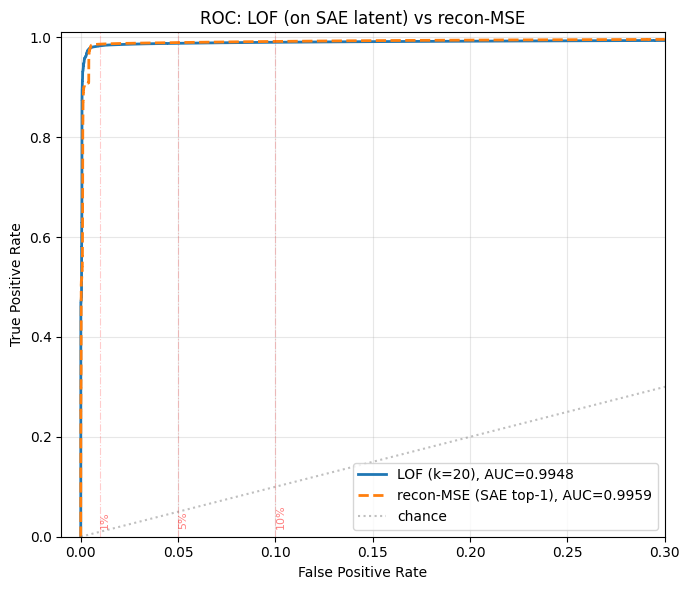

✓ Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week5/05_k_ablation.png


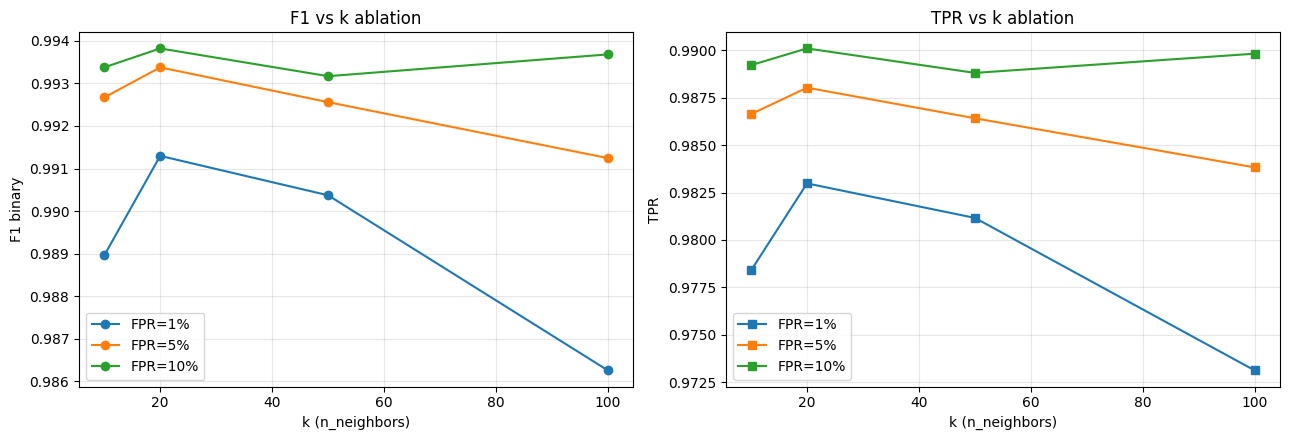

In [11]:
# Plot 1: ROC overlay
fig, ax = plt.subplots(figsize=(7, 6))

# LOF best k
fpr_lof, tpr_lof, _ = roc_curve(y_binary, all_scores[best_k])
ax.plot(fpr_lof, tpr_lof, lw=2,
        label=f'LOF (k={best_k}), AUC={fit_stats[best_k]["auc_binary"]:.4f}')

# Recon-MSE (nếu có)
if recon_scores is not None:
    fpr_r, tpr_r, _ = roc_curve(y_binary, recon_scores)
    ax.plot(fpr_r, tpr_r, lw=2, linestyle='--',
            label=f'recon-MSE (SAE top-1), AUC={recon_auc:.4f}')

# Diagonal chance
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5, label='chance')

# Mark FPR targets
for fpr_t in FPR_TARGETS:
    ax.axvline(x=fpr_t, color='red', alpha=0.2, linestyle='-.', linewidth=0.8)
    ax.text(fpr_t, 0.02, f'{int(fpr_t*100)}%', color='red', alpha=0.5, fontsize=8, rotation=90)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: LOF (on SAE latent) vs recon-MSE')
ax.set_xlim([-0.01, 0.3])  # zoom vào low-FPR region (area of interest)
ax.set_ylim([0, 1.01])
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
out = FIG_DIR / '05_roc_overlay.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'✓ Saved {out}')
plt.show()

# Plot 2: k ablation — F1 vs k at each FPR target
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for fpr_t in FPR_TARGETS:
    sub = ablation_df[np.isclose(ablation_df['fpr_target'], fpr_t)].sort_values('k')
    axes[0].plot(sub['k'], sub['f1_binary'], marker='o', label=f'FPR={int(fpr_t*100)}%')
    axes[1].plot(sub['k'], sub['tpr'], marker='s', label=f'FPR={int(fpr_t*100)}%')

axes[0].set_xlabel('k (n_neighbors)')
axes[0].set_ylabel('F1 binary')
axes[0].set_title('F1 vs k ablation')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('k (n_neighbors)')
axes[1].set_ylabel('TPR')
axes[1].set_title('TPR vs k ablation')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
out = FIG_DIR / '05_k_ablation.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'✓ Saved {out}')
plt.show()

### Cell 12 — Confusion matrices (8-class & 34-class)

✓ Saved /content/drive/MyDrive/sae-lof-ids-pi5/figs/week5/05_confmat_and_recall.png


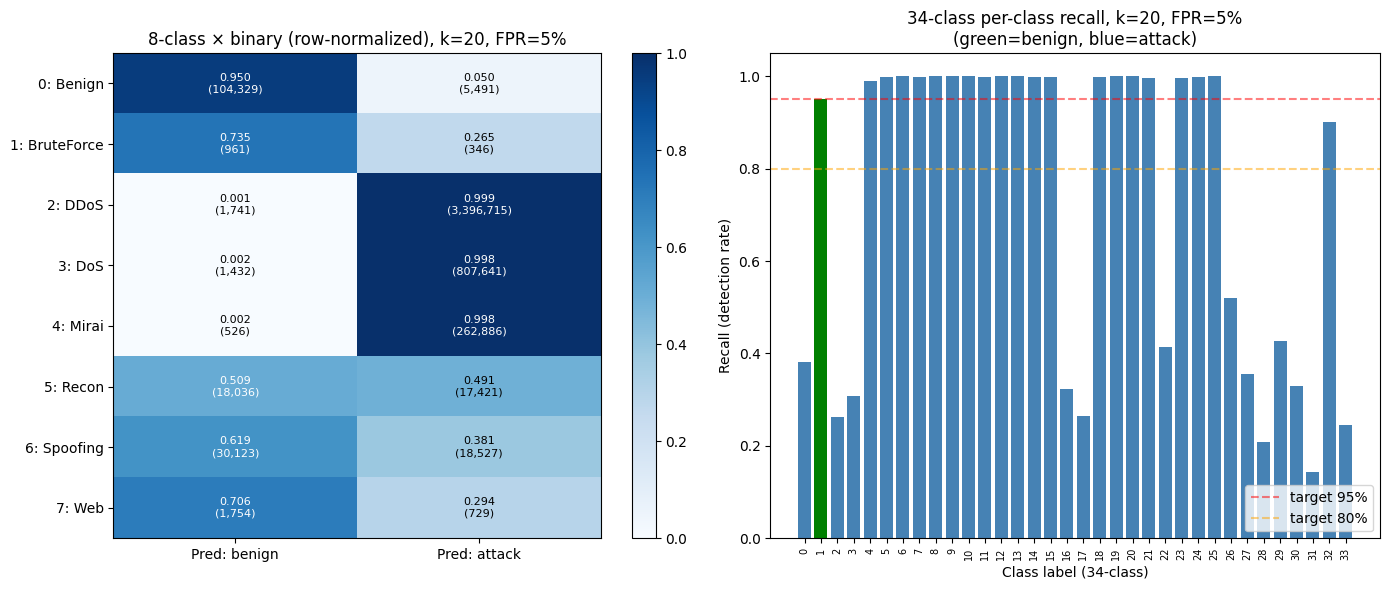

In [12]:
# 8-class confusion matrix (binary prediction × multi-class true label)
# Rows = true label, cols = predicted binary {benign=0, attack=1}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Build 8×2 matrix
cm8 = np.zeros((len(class_names_8), 2), dtype=np.int64)
for lab in sorted(class_names_8.keys()):
    mask = (y8 == lab)
    cm8[lab, 0] = int((y_pred_bin[mask] == 0).sum())
    cm8[lab, 1] = int((y_pred_bin[mask] == 1).sum())

# Normalize rows
cm8_norm = cm8 / cm8.sum(axis=1, keepdims=True)

im = axes[0].imshow(cm8_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Pred: benign', 'Pred: attack'])
axes[0].set_yticks(range(len(class_names_8)))
axes[0].set_yticklabels([f'{i}: {class_names_8[i]}' for i in sorted(class_names_8)])
axes[0].set_title(f'8-class × binary (row-normalized), k={best_k}, FPR=5%')
for i in range(len(class_names_8)):
    for j in range(2):
        text_color = 'white' if cm8_norm[i, j] > 0.5 else 'black'
        axes[0].text(j, i, f'{cm8_norm[i,j]:.3f}\n({cm8[i,j]:,})',
                     ha='center', va='center', fontsize=8, color=text_color)
plt.colorbar(im, ax=axes[0])

# 34-class: show recall bar chart (since 34×2 matrix is too sparse to read)
pc34_sorted = pc34_df.sort_values('label')
colors = ['green' if r['is_benign'] else 'steelblue' for _, r in pc34_sorted.iterrows()]
bars = axes[1].bar(pc34_sorted['label'].astype(str), pc34_sorted['recall'], color=colors)
axes[1].set_xlabel('Class label (34-class)')
axes[1].set_ylabel('Recall (detection rate)')
axes[1].set_title(f'34-class per-class recall, k={best_k}, FPR=5%\n(green=benign, blue=attack)')
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='target 95%')
axes[1].axhline(y=0.80, color='orange', linestyle='--', alpha=0.5, label='target 80%')
axes[1].set_ylim([0, 1.05])
axes[1].legend(loc='lower right')
axes[1].tick_params(axis='x', labelrotation=90, labelsize=7)

plt.tight_layout()
out = FIG_DIR / '05_confmat_and_recall.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'✓ Saved {out}')
plt.show()

### Cell 13 — Final summary JSON + checklist

In [13]:
# Build summary
final = {
    'week': 5,
    'timestamp': time.strftime('%Y-%m-%d %H:%M'),
    'sae_top1': {'rho': float(top1['rho']), 'beta': float(top1['beta'])},
    'lof_config': {
        'sample_size_fit': SAMPLE_SIZE_FIT,
        'k_values_tested': K_VALUES,
        'best_k': best_k,
        'algorithm': 'ball_tree',
        'metric': 'minkowski p=2',
        'standardscaler': True,
    },
    'data': {
        'n_val_total': int(len(y8)),
        'n_val_benign': int(n_benign_val),
        'n_val_attack': int(n_attack_val),
    },
    'best_k_metrics': {},
    'ablation_summary': {},
}

# Best k metrics at all 3 FPR targets
for fpr_t in FPR_TARGETS:
    row = ablation_df[(ablation_df['k'] == best_k) &
                      np.isclose(ablation_df['fpr_target'], fpr_t)].iloc[0]
    final['best_k_metrics'][f'fpr_{int(fpr_t*100)}pct'] = {
        'threshold': float(row['threshold']),
        'tpr': float(row['tpr']),
        'fpr_actual': float(row['fpr_actual']),
        'precision': float(row['precision']),
        'f1_binary': float(row['f1_binary']),
        'tp': int(row['tp']), 'fp': int(row['fp']),
        'tn': int(row['tn']), 'fn': int(row['fn']),
    }
final['best_k_metrics']['auc_binary'] = float(ablation_df[ablation_df['k']==best_k].iloc[0]['auc_binary'])
final['best_k_metrics']['fit_time_s'] = float(fit_stats[best_k]['fit_time_s'])
final['best_k_metrics']['score_time_s_4_67M'] = float(fit_stats[best_k]['score_time_s'])

# Ablation summary (all k)
for k in K_VALUES:
    rows_k = ablation_df[ablation_df['k'] == k]
    final['ablation_summary'][f'k={k}'] = {
        'auc_binary': float(rows_k.iloc[0]['auc_binary']),
        'fit_time_s': float(fit_stats[k]['fit_time_s']),
        'score_time_s': float(fit_stats[k]['score_time_s']),
        'f1_at_fpr5': float(rows_k[np.isclose(rows_k['fpr_target'], 0.05)].iloc[0]['f1_binary']),
        'tpr_at_fpr5': float(rows_k[np.isclose(rows_k['fpr_target'], 0.05)].iloc[0]['tpr']),
    }

# Vs recon baseline
if recon_scores is not None:
    final['vs_recon_mse'] = {
        'recon_auc': float(recon_auc),
        'lof_best_k_auc': float(final['best_k_metrics']['auc_binary']),
        'auc_diff': float(final['best_k_metrics']['auc_binary'] - recon_auc),
    }
else:
    final['vs_recon_mse'] = {
        'note': 'recon scores not available; used Week 4 summary AUC only',
        'recon_auc_from_w4': float(top1['auc']),
        'lof_best_k_auc': float(final['best_k_metrics']['auc_binary']),
    }

final_fp = RESULT_DIR / 'week5_final_summary.json'
with open(final_fp, 'w') as f:
    json.dump(final, f, indent=2)
print(f'✓ Saved: {final_fp}')
print()
print(json.dumps(final, indent=2))

✓ Saved: /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_final_summary.json

{
  "week": 5,
  "timestamp": "2026-04-24 21:17",
  "sae_top1": {
    "rho": 0.05,
    "beta": 1.0
  },
  "lof_config": {
    "sample_size_fit": 100000,
    "k_values_tested": [
      10,
      20,
      50,
      100
    ],
    "best_k": 20,
    "algorithm": "ball_tree",
    "metric": "minkowski p=2",
    "standardscaler": true
  },
  "data": {
    "n_val_total": 4668658,
    "n_val_benign": 109820,
    "n_val_attack": 4558838
  },
  "best_k_metrics": {
    "fpr_1pct": {
      "threshold": 1.7681589126586914,
      "tpr": 0.9829811895048695,
      "fpr_actual": 0.010007284647605173,
      "precision": 0.9997548161667839,
      "f1_binary": 0.9912970517483928,
      "tp": 4481252,
      "fp": 1099,
      "tn": 108721,
      "fn": 77586
    },
    "fpr_5pct": {
      "threshold": 1.3507124185562134,
      "tpr": 0.9880291863847761,
      "fpr_actual": 0.05,
      "precision": 0.9987824174966451,
    

### Cell 14 — Deliverable checklist

In [14]:
checklist = {
    'Ablation CSV'           : ABLATION_CSV,
    'Vs-recon CSV'           : COMPARE_CSV,
    'Per-class 8 CSV'        : RESULT_DIR / 'week5_per_class_8.csv',
    'Per-class 34 CSV'       : RESULT_DIR / 'week5_per_class_34.csv',
    'Final JSON'             : final_fp,
    'LOF scores (best k)'    : RESULT_DIR / f'lof_scores_val_k={best_k}.npy',
    'LOF scores (canonical)' : RESULT_DIR / 'lof_scores_val.npy',
    'Scaler pkl'             : SCALER_FP,
    'ROC overlay'            : FIG_DIR / '05_roc_overlay.png',
    'K ablation plot'        : FIG_DIR / '05_k_ablation.png',
    'Confmat + recall'       : FIG_DIR / '05_confmat_and_recall.png',
}
for k in K_VALUES:
    checklist[f'LOF model k={k}'] = CKPT_DIR / f'lof_k={k}.pkl'

n_ok = 0
print(f'{"Status":<6} {"Artifact":<25} Path  (size)')
print('-' * 100)
for name, path in checklist.items():
    ok = path.exists()
    n_ok += int(ok)
    mark = '✓' if ok else '✗'
    size = f'{path.stat().st_size/1e6:.1f} MB' if ok else '-'
    print(f'{mark:<6} {name:<25} {path}  ({size})')

print(f'\n{n_ok}/{len(checklist)} artifacts present')
if n_ok == len(checklist):
    print('\n🎉 WEEK 5 COMPLETE')
else:
    print('\n⚠ Some artifacts missing — re-run corresponding cells')

Status Artifact                  Path  (size)
----------------------------------------------------------------------------------------------------
✓      Ablation CSV              /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_lof_ablation.csv  (0.0 MB)
✓      Vs-recon CSV              /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_lof_vs_recon.csv  (0.0 MB)
✓      Per-class 8 CSV           /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_per_class_8.csv  (0.0 MB)
✓      Per-class 34 CSV          /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_per_class_34.csv  (0.0 MB)
✓      Final JSON                /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_final_summary.json  (0.0 MB)
✓      LOF scores (best k)       /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/lof_scores_val_k=20.npy  (18.7 MB)
✓      LOF scores (canonical)    /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/lof_scores_val.npy  (18.7 MB)
✓      Scaler pkl   

### Cell 15 — Week 6 preview

In [15]:
print('='*60)
print('WEEK 6 PLAN (27/05–02/06): Baseline retraining')
print('='*60)
print(f'Baselines to retrain on same 80/10/10 split:')
print(f'  1. Isolation Forest (sklearn, n_estimators=100)')
print(f'  2. One-Class SVM (RBF, nu=0.05)')
print(f'  3. Vanilla AE + threshold (μ+3σ) — SAE without KL penalty')
print(f'  4. DNN-Neto 2023 (MLP 64-32-NC)')
print(f'  5. Stacked-LSTM-Musthafa 2025 (128-64 + PTQ-INT8 + 50% prune)')
print(f'  6. CNN-Albanbay 2025 (CNN+BiLSTM)')
print()
print(f'Target: same 3 FPR targets {FPR_TARGETS} for consistent comparison')
print(f'Output: results/week6/week6_baselines.csv với F1, AUC, #params, latency')
print()
print(f'Week 5 artifacts needed:')
print(f'  ✓ scaler_z.pkl (if baselines use latent — but IF/OC-SVM on raw X46)')
print(f'  ✓ lof_scores_val.npy (for Pareto plot Week 10)')
print(f'  ✓ y_binary / y_val_8 / y_val_34 (same labels)')

WEEK 6 PLAN (27/05–02/06): Baseline retraining
Baselines to retrain on same 80/10/10 split:
  1. Isolation Forest (sklearn, n_estimators=100)
  2. One-Class SVM (RBF, nu=0.05)
  3. Vanilla AE + threshold (μ+3σ) — SAE without KL penalty
  4. DNN-Neto 2023 (MLP 64-32-NC)
  5. Stacked-LSTM-Musthafa 2025 (128-64 + PTQ-INT8 + 50% prune)
  6. CNN-Albanbay 2025 (CNN+BiLSTM)

Target: same 3 FPR targets [0.01, 0.05, 0.1] for consistent comparison
Output: results/week6/week6_baselines.csv với F1, AUC, #params, latency

Week 5 artifacts needed:
  ✓ scaler_z.pkl (if baselines use latent — but IF/OC-SVM on raw X46)
  ✓ lof_scores_val.npy (for Pareto plot Week 10)
  ✓ y_binary / y_val_8 / y_val_34 (same labels)


### Cell 16 — Ensemble recon-MSE + LOF

In [16]:
# ============================================================
# Cell 16 — Ensemble: recon-MSE + LOF
# ============================================================
# Thử 3 fusion strategies:
#   (a) Simple average sau min-max normalize
#   (b) Weighted average (grid search α)
#   (c) Max (union of alarms)
# Mục tiêu: check xem ensemble có vượt recon-MSE đơn lẻ (AUC 0.99587) không
# ============================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, roc_curve

# Load scores
recon_errs = np.load(WEEK4_DIR / 'recon_err_val_seed0.npy').astype(np.float32)
lof_scores = np.load(RESULT_DIR / 'lof_scores_val.npy').astype(np.float32)
y_binary   = (y8 != BENIGN_LABEL).astype(np.int8)

assert len(recon_errs) == len(lof_scores) == len(y_binary)

# --- Normalize to [0,1] để 2 scorer comparable ---
# Fit scaler chỉ trên val-benign (đừng để attack extremes dominate range)
# → giữ distribution shape của benign, không "flatten" outliers
mask_benign = (y8 == BENIGN_LABEL)

def robust_minmax(scores, benign_mask, clip_pct=99.9):
    """Scale to [0,1] using benign's [min, clip_pct percentile].
    Điều này chống outlier extremes phá scale."""
    lo = scores[benign_mask].min()
    hi = np.percentile(scores[benign_mask], clip_pct)
    s = (scores - lo) / (hi - lo + 1e-12)
    return np.clip(s, 0, None).astype(np.float32)  # allow >1 for attacks

s_recon = robust_minmax(recon_errs, mask_benign)
s_lof   = robust_minmax(lof_scores, mask_benign)

print(f'Normalized scores:')
print(f'  s_recon: benign median={np.median(s_recon[mask_benign]):.4f}, '
      f'attack median={np.median(s_recon[~mask_benign]):.4f}')
print(f'  s_lof  : benign median={np.median(s_lof[mask_benign]):.4f}, '
      f'attack median={np.median(s_lof[~mask_benign]):.4f}')

# --- Strategy (a): simple average ---
s_avg = 0.5 * s_recon + 0.5 * s_lof
auc_avg = roc_auc_score(y_binary, s_avg)

# --- Strategy (b): weighted grid search alpha ---
alphas = np.linspace(0.0, 1.0, 11)  # α=weight of recon; 1-α = weight of LOF
alpha_results = []
for alpha in alphas:
    s = alpha * s_recon + (1 - alpha) * s_lof
    auc = roc_auc_score(y_binary, s)
    alpha_results.append({'alpha_recon': alpha, 'auc': auc})
alpha_df = pd.DataFrame(alpha_results)
best_alpha_row = alpha_df.loc[alpha_df['auc'].idxmax()]
best_alpha = float(best_alpha_row['alpha_recon'])
s_best = best_alpha * s_recon + (1 - best_alpha) * s_lof
auc_best = float(best_alpha_row['auc'])

# --- Strategy (c): max fusion (union of alarms) ---
s_max = np.maximum(s_recon, s_lof)
auc_max = roc_auc_score(y_binary, s_max)

# --- Baseline AUCs for reference ---
auc_recon_alone = roc_auc_score(y_binary, recon_errs)
auc_lof_alone   = roc_auc_score(y_binary, lof_scores)

print('\n=== Ensemble AUC comparison ===')
print(f'  recon-MSE alone    : {auc_recon_alone:.6f}  (baseline)')
print(f'  LOF alone          : {auc_lof_alone:.6f}')
print(f'  Ensemble: avg      : {auc_avg:.6f}  (Δ={auc_avg - auc_recon_alone:+.6f})')
print(f'  Ensemble: best α={best_alpha:.1f}: {auc_best:.6f}  (Δ={auc_best - auc_recon_alone:+.6f})')
print(f'  Ensemble: max      : {auc_max:.6f}  (Δ={auc_max - auc_recon_alone:+.6f})')

print('\n=== Alpha grid search (α = weight of recon) ===')
print(alpha_df.to_string(index=False, float_format='%.6f'))

Normalized scores:
  s_recon: benign median=0.0099, attack median=3.3648
  s_lof  : benign median=0.0504, attack median=1.4528

=== Ensemble AUC comparison ===
  recon-MSE alone    : 0.995871  (baseline)
  LOF alone          : 0.994760
  Ensemble: avg      : 0.995995  (Δ=+0.000125)
  Ensemble: best α=0.8: 0.996130  (Δ=+0.000259)
  Ensemble: max      : 0.995340  (Δ=-0.000531)

=== Alpha grid search (α = weight of recon) ===
 alpha_recon      auc
    0.000000 0.994760
    0.100000 0.995278
    0.200000 0.995533
    0.300000 0.995726
    0.400000 0.995878
    0.500000 0.995995
    0.600000 0.996075
    0.700000 0.996119
    0.800000 0.996130
    0.900000 0.996078
    1.000000 0.995871


### Cell 17 — Ensemble @ 3 FPR targets + per-class + save

Winning strategy: weighted_alpha0.8 (AUC=0.996130)
  FPR= 1.0%  τ= 0.2481  TPR= 98.65%  F1=0.99310
  FPR= 5.0%  τ= 0.1096  TPR= 99.00%  F1=0.99438
  FPR=10.0%  τ= 0.0662  TPR= 99.21%  F1=0.99485

=== Per-class recall (8-class) — Ensemble vs LOF vs recon ===
class               recon       LOF  ensemble  Δ(ens-LOF)
Benign             0.9500    0.9500    0.9500     +0.0000
BruteForce         0.3137    0.2647    0.3236     +0.0589
DDoS               1.0000    0.9995    1.0000     +0.0005
DoS                1.0000    0.9982    1.0000     +0.0018
Mirai              1.0000    0.9980    1.0000     +0.0020
Recon              0.5722    0.4913    0.5795     +0.0881
Spoofing           0.3826    0.3808    0.4235     +0.0427
Web                0.3323    0.2936    0.3532     +0.0596

✓ Saved ensemble artifacts:
  /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_ensemble_metrics.csv
  /content/drive/MyDrive/sae-lof-ids-pi5/results/week5/week5_ensemble_per_class_8.csv
  /content/drive/MyDriv

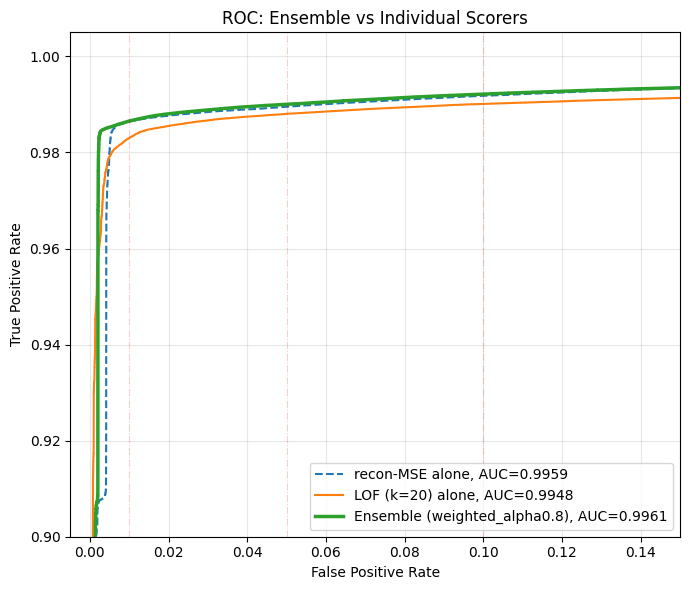

In [17]:
# ============================================================
# Cell 17 — Ensemble metrics @ 3 FPR, per-class, save artifacts
# ============================================================
# Dùng strategy tốt nhất (max AUC) để tính full metrics
# ============================================================
# Pick winning ensemble
strategies = {
    'avg': s_avg,
    f'weighted_alpha{best_alpha:.1f}': s_best,
    'max': s_max,
}
strategy_aucs = {'avg': auc_avg, f'weighted_alpha{best_alpha:.1f}': auc_best, 'max': auc_max}
best_strategy = max(strategy_aucs, key=strategy_aucs.get)
s_ensemble = strategies[best_strategy]
auc_ensemble = strategy_aucs[best_strategy]
print(f'Winning strategy: {best_strategy} (AUC={auc_ensemble:.6f})')

# Compute metrics at 3 FPR targets (reuse helpers from Cell 6)
ensemble_results = []
for fpr_target in FPR_TARGETS:
    tau = threshold_at_fpr(s_ensemble[mask_benign], fpr_target)
    m = binary_metrics_at_threshold(y_binary, s_ensemble, tau)
    ensemble_results.append({
        'scorer': f'ensemble_{best_strategy}',
        'fpr_target': fpr_target,
        'threshold': float(tau),
        'auc': float(auc_ensemble),
        'tpr': m['tpr'],
        'fpr_actual': m['fpr_actual'],
        'precision': m['precision'],
        'f1_binary': m['f1_binary'],
        'tp': m['tp'], 'fp': m['fp'], 'tn': m['tn'], 'fn': m['fn'],
    })
    print(f'  FPR={fpr_target*100:4.1f}%  τ={tau:7.4f}  '
          f'TPR={m["tpr"]*100:6.2f}%  F1={m["f1_binary"]:.5f}')

ensemble_df = pd.DataFrame(ensemble_results)

# --- Per-class recall @ FPR=5% for ensemble ---
tau_5 = ensemble_df[np.isclose(ensemble_df['fpr_target'], 0.05)].iloc[0]['threshold']
y_pred_ens = (s_ensemble > tau_5).astype(np.int8)

print(f'\n=== Per-class recall (8-class) — Ensemble vs LOF vs recon ===')
print(f'{"class":<15}{"recon":>10}{"LOF":>10}{"ensemble":>10}{"Δ(ens-LOF)":>12}')

# Need y_pred for recon and LOF at FPR=5% to compare
tau_recon = threshold_at_fpr(recon_errs[mask_benign], 0.05)
tau_lof   = threshold_at_fpr(lof_scores[mask_benign], 0.05)
y_pred_recon = (recon_errs > tau_recon).astype(np.int8)
y_pred_lof   = (lof_scores > tau_lof).astype(np.int8)

per_class_compare = []
for lab in sorted(class_names_8.keys()):
    mask = (y8 == lab)
    total = int(mask.sum())
    if lab == BENIGN_LABEL:
        rec_recon = (y_pred_recon[mask] == 0).mean()
        rec_lof   = (y_pred_lof[mask] == 0).mean()
        rec_ens   = (y_pred_ens[mask] == 0).mean()
    else:
        rec_recon = (y_pred_recon[mask] == 1).mean()
        rec_lof   = (y_pred_lof[mask] == 1).mean()
        rec_ens   = (y_pred_ens[mask] == 1).mean()
    per_class_compare.append({
        'label': lab, 'name': class_names_8[lab], 'n_total': total,
        'recall_recon': rec_recon, 'recall_lof': rec_lof, 'recall_ensemble': rec_ens,
        'delta_ens_lof': rec_ens - rec_lof,
    })
    name = class_names_8[lab]
    print(f'{name:<15}{rec_recon:>10.4f}{rec_lof:>10.4f}{rec_ens:>10.4f}{rec_ens-rec_lof:>+12.4f}')

per_class_df = pd.DataFrame(per_class_compare)

# --- Save artifacts (new files, không ghi đè Week 5 cũ) ---
ENSEMBLE_CSV    = RESULT_DIR / 'week5_ensemble_metrics.csv'
ENSEMBLE_PC_CSV = RESULT_DIR / 'week5_ensemble_per_class_8.csv'
ALPHA_CSV       = RESULT_DIR / 'week5_ensemble_alpha_grid.csv'
ENSEMBLE_JSON   = RESULT_DIR / 'week5_ensemble_summary.json'
ENSEMBLE_SCORES = RESULT_DIR / 'ensemble_scores_val.npy'

ensemble_df.to_csv(ENSEMBLE_CSV, index=False)
per_class_df.to_csv(ENSEMBLE_PC_CSV, index=False)
alpha_df.to_csv(ALPHA_CSV, index=False)
np.save(ENSEMBLE_SCORES, s_ensemble.astype(np.float32))

ensemble_summary = {
    'week': 5,
    'addendum': 'ensemble',
    'timestamp': time.strftime('%Y-%m-%d %H:%M'),
    'strategies_tested': {
        'avg_0.5_0.5': float(auc_avg),
        f'weighted_alpha_{best_alpha:.1f}': float(auc_best),
        'max': float(auc_max),
    },
    'best_strategy': best_strategy,
    'best_auc': float(auc_ensemble),
    'best_alpha': float(best_alpha) if 'weighted' in best_strategy else None,
    'baselines': {
        'recon_mse_alone_auc': float(auc_recon_alone),
        'lof_alone_auc': float(auc_lof_alone),
    },
    'delta_vs_recon_alone': float(auc_ensemble - auc_recon_alone),
    'metrics_at_fpr': {
        f'fpr_{int(fpr*100)}pct': {
            'threshold': float(r['threshold']),
            'tpr': float(r['tpr']),
            'f1_binary': float(r['f1_binary']),
            'precision': float(r['precision']),
        }
        for fpr, r in zip(FPR_TARGETS, ensemble_results)
    },
}
with open(ENSEMBLE_JSON, 'w') as f:
    json.dump(ensemble_summary, f, indent=2)

print(f'\n✓ Saved ensemble artifacts:')
print(f'  {ENSEMBLE_CSV}')
print(f'  {ENSEMBLE_PC_CSV}')
print(f'  {ALPHA_CSV}')
print(f'  {ENSEMBLE_JSON}')
print(f'  {ENSEMBLE_SCORES}')

# --- Plot: ROC overlay with ensemble ---
fig, ax = plt.subplots(figsize=(7, 6))
for label, scores, style in [
    (f'recon-MSE alone, AUC={auc_recon_alone:.4f}', recon_errs, '--'),
    (f'LOF (k={best_k}) alone, AUC={auc_lof_alone:.4f}', lof_scores, '-'),
    (f'Ensemble ({best_strategy}), AUC={auc_ensemble:.4f}', s_ensemble, '-'),
]:
    fpr, tpr, _ = roc_curve(y_binary, scores)
    lw = 2.5 if 'Ensemble' in label else 1.5
    ax.plot(fpr, tpr, linestyle=style, lw=lw, label=label)

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', alpha=0.5)
for fpr_t in FPR_TARGETS:
    ax.axvline(x=fpr_t, color='red', alpha=0.2, linestyle='-.', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Ensemble vs Individual Scorers')
ax.set_xlim([-0.005, 0.15])
ax.set_ylim([0.9, 1.005])
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
out = FIG_DIR / '05b_ensemble_roc.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'\n✓ Saved {out}')
plt.show()